<a href="https://colab.research.google.com/github/greek-nlp/benchmark/blob/main/legal_text_classification_colab_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Greek Legal Text Classification in Colab

This notebook is a dedicated Colab entrypoint for the legal text classification benchmark in this repository.

Current state:
- The notebook sets up Ollama inside Colab.
- It benchmarks legal text classification on the `AI-team-UoA/greek_legal_code` dataset.
- It repeats runs multiple times and reports mean and SEM, following the same Monte Carlo setup style as the suite notebook.


## Quick Start

Run the notebook top to bottom:
1. Setup cells
2. Benchmark configuration
3. Model pull cell
4. Task overview
5. Benchmark execution and results cells

Important: in Ollama, use `llama3.1:8b`, not `llama3.1:8b-instruct`.


## Repo Setup

Open this notebook from the repository in Colab, or clone/upload the repository files into the runtime before continuing.


## 1. Environment Setup


In [1]:
!apt-get -qq update
!apt-get -qq install -y zstd


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
!pip -q install pandas pywer openpyxl datasets scikit-learn matplotlib seaborn


In [3]:
!curl -fsSL https://ollama.com/install.sh | sh


>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [4]:
import subprocess
import time

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
time.sleep(5)
print("Started Ollama server with PID", ollama_process.pid)


Started Ollama server with PID 2925


## 2. Benchmark Configuration


In [5]:
from pathlib import Path
import sys
import pandas as pd

project_root = Path.cwd()
print("Working directory:", project_root)
print("Python executable:", sys.executable)

MODEL_PRESETS = {
    "t4": [
        "qwen2.5:3b",
        "gemma2:2b",
        "mistral:7b",
        "qwen2.5:7b-instruct",
    ],
    "high_memory": [
        "llama3.1:8b",
        "aya-expanse:8b",
        "gemma2:9b",
        "qwen2.5:14b",
    ],
}

TASK_INFO = {
    "task": "legal_text_classification",
    "dataset": "AI-team-UoA/greek_legal_code",
    "subset": "subject",
    "labels_from": "dataset split in use",
}

MODEL_PRESET = "t4"
MODELS = MODEL_PRESETS[MODEL_PRESET]

SAMPLE_SIZE = 100
NUM_REPEATS = 5
RANDOM_STATE = 42
RESUME_REPEATS = True
OUTPUT_ROOT = Path("results/legal_text_classification_colab")

print("Model preset:", MODEL_PRESET)
print("Models:", MODELS)
print("Task:", TASK_INFO["task"])
print("Dataset:", TASK_INFO["dataset"], "subset:", TASK_INFO["subset"])
print("Sample size:", SAMPLE_SIZE)
print("Repeats per task:", NUM_REPEATS)
print("Resume existing repeats:", RESUME_REPEATS)


Working directory: /content
Python executable: /usr/bin/python3
Model preset: t4
Models: ['qwen2.5:3b', 'gemma2:2b', 'mistral:7b', 'qwen2.5:7b-instruct']
Task: legal_text_classification
Dataset: AI-team-UoA/greek_legal_code subset: subject
Sample size: 100
Repeats per task: 5
Resume existing repeats: True


In [6]:
for model in MODELS:
    print(f"Pulling {model}...")
    subprocess.run(["ollama", "pull", model], check=True)


Pulling qwen2.5:3b...
Pulling gemma2:2b...
Pulling mistral:7b...
Pulling qwen2.5:7b-instruct...


In [7]:
!ollama list


NAME                   ID              SIZE      MODIFIED               
qwen2.5:7b-instruct    845dbda0ea48    4.7 GB    Less than a second ago    
mistral:7b             6577803aa9a0    4.4 GB    30 seconds ago            
gemma2:2b              8ccf136fdd52    1.6 GB    About a minute ago        
qwen2.5:3b             357c53fb659c    1.9 GB    About a minute ago        


## 3. Task Overview


In [8]:
pd.DataFrame([TASK_INFO])


,task,dataset,subset,labels_from
0,legal_text_classification,AI-team-UoA/greek_legal_code,subject,dataset split in use


## 4. Run Legal Text Classification


In [9]:
import os

repo_url = "https://github.com/greek-nlp/benchmark.git"
repo_dir = "benchmark"

if not os.path.exists(repo_dir):
    print(f"Cloning {repo_url} into {repo_dir}...")
    !git clone {repo_url}
    %cd {repo_dir}
    print(f"Changed current working directory to {os.getcwd()}")
else:
    print(f"Repository {repo_dir} already exists. Pulling latest changes...")
    %cd {repo_dir}
    !git pull
    print(f"Current working directory is {os.getcwd()}")


Cloning https://github.com/greek-nlp/benchmark.git into benchmark...
Cloning into 'benchmark'...
remote: Enumerating objects: 376, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 376 (delta 22), reused 19 (delta 8), pack-reused 336 (from 2)
Receiving objects: 100% (376/376), 21.25 MiB | 48.57 MiB/s, done.
Resolving deltas: 100% (213/213), done.
/content/benchmark
Changed current working directory to /content/benchmark


In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from benchmark_suite import GenerationConfig, save_run_outputs
from benchmark_suite.backends import OllamaBackend

def aggregate_repeated_summaries(summary_by_repeat):
    repeated_summary = pd.concat(summary_by_repeat, ignore_index=True)
    key_columns = [column for column in ["task", "model"] if column in repeated_summary.columns]
    numeric_columns = [
        column
        for column in repeated_summary.columns
        if column not in key_columns + ["repeat"] and pd.api.types.is_numeric_dtype(repeated_summary[column])
    ]

    aggregated = repeated_summary[key_columns].drop_duplicates().sort_values(key_columns).reset_index(drop=True)
    for column in numeric_columns:
        stats = (
            repeated_summary.groupby(key_columns, dropna=False)[column]
            .agg(["mean", "sem"])
            .reset_index()
            .rename(columns={"mean": f"{column}_mean", "sem": f"{column}_sem"})
        )
        aggregated = aggregated.merge(stats, on=key_columns, how="left")
    return aggregated, repeated_summary

def load_repeat_outputs(repeat_output_dir, task_name):
    summary = pd.read_csv(repeat_output_dir / f"{task_name}_summary.csv")
    raw = pd.read_csv(repeat_output_dir / f"{task_name}_predictions.csv")
    return summary, raw

def load_legal_split(split_name):
    subset_frames = []
    for subset in ["volume", "chapter", "subject"]:
        subset_dataset = load_dataset("AI-team-UoA/greek_legal_code", subset)
        resolved_split = split_name if split_name in subset_dataset else next(iter(subset_dataset.keys()))
        subset_frame = pd.DataFrame(subset_dataset[resolved_split]).rename(columns={"label": subset})
        keep_columns = [column for column in ["text", subset] if column in subset_frame.columns]
        subset_frames.append(subset_frame[keep_columns].reset_index(drop=True))

    merged = subset_frames[0]
    for subset_frame in subset_frames[1:]:
        merged = merged.merge(subset_frame, left_index=True, right_index=True, how="inner")

    text_columns = [column for column in merged.columns if column.startswith("text")]
    if "text" not in merged.columns and text_columns:
        merged["text"] = merged[text_columns[0]]
    drop_columns = [column for column in text_columns if column != "text"]
    if drop_columns:
        merged = merged.drop(columns=drop_columns)

    return merged[["text", "volume", "chapter", "subject"]].dropna().reset_index(drop=True)


def prepare_legal_dataset(random_state):
    split_name = "test"
    df = load_legal_split(split_name)
    if SAMPLE_SIZE and SAMPLE_SIZE < len(df):
        df = df.sample(SAMPLE_SIZE, random_state=random_state).reset_index(drop=True)
    label_space = sorted(df["subject"].astype(str).str.strip().unique())
    return df, label_space, split_name

def build_prompt(example, label_list):
    return (
        "Given the following Greek legal text, return only its legal subject label.\n"
        f"Choose exactly one label from: {label_list}\n\n"
        f"Text: {example['text']}\n"
        "Label:"
    )

def normalize_label(value):
    return " ".join(str(value).split()).strip()


def normalize_prediction(prediction, label_space):
    cleaned = " ".join(str(prediction).split()).strip()
    for label in label_space:
        if cleaned.lower() == label.lower():
            return label
    lowered = cleaned.lower()
    for label in label_space:
        if label.lower() in lowered:
            return label
    return cleaned

def run_legal_task(models, random_state):
    legal_df, label_space, split_name = prepare_legal_dataset(random_state)
    label_space = [normalize_label(label) for label in label_space]
    legal_df = legal_df.copy()
    legal_df["subject"] = legal_df["subject"].map(normalize_label)
    label_list = ", ".join(label_space)
    backend = OllamaBackend()
    config = GenerationConfig(temperature=0.0, num_predict=64, timeout_seconds=300)

    records = []
    for model in models:
        for row in legal_df.itertuples(index=False):
            example = row._asdict()
            result = backend.generate(
                model=model,
                prompt=build_prompt(example, label_list),
                system_prompt=(
                    "You are a Greek legal text classification system. "
                    "Return only one label from the provided label set and nothing else."
                ),
                temperature=config.temperature,
                num_predict=config.num_predict,
                timeout_seconds=config.timeout_seconds,
            )
            records.append(
                {
                    "task": "legal_text_classification",
                    "model": model,
                    "prediction": normalize_prediction(result.response, label_space),
                    "latency_seconds": result.latency_seconds,
                    **example,
                }
            )

    raw = pd.DataFrame.from_records(records)
    raw["subject"] = raw["subject"].map(normalize_label)
    raw["prediction"] = raw["prediction"].map(normalize_label)
    summary = pd.DataFrame(
        [
            {
                "task": "legal_text_classification",
                "model": model,
                "samples": len(group),
                "accuracy": accuracy_score(group["subject"], group["prediction"]),
                "macro_f1": f1_score(group["subject"], group["prediction"], average="macro", zero_division=0),
                "avg_latency_seconds": group["latency_seconds"].mean(),
            }
            for model, group in raw.groupby("model", sort=False)
        ]
    ).sort_values(["accuracy", "macro_f1"], ascending=[False, False]).reset_index(drop=True)
    return summary, raw, split_name


In [16]:
task_name = "legal_text_classification"
repeat_summaries = []
repeat_predictions = []
split_names = []

for repeat_index in range(NUM_REPEATS):
    repeat_number = repeat_index + 1
    repeat_seed = RANDOM_STATE + repeat_index
    repeat_output_dir = OUTPUT_ROOT / task_name / f"repeat_{repeat_number:02d}"

    if RESUME_REPEATS and (repeat_output_dir / f"{task_name}_summary.csv").exists():
        print(f"Reusing repeat {repeat_number}/{NUM_REPEATS} from {repeat_output_dir}")
        summary, raw = load_repeat_outputs(repeat_output_dir, task_name)
        split_name = "cached"
    else:
        print(f"Running repeat {repeat_number}/{NUM_REPEATS} with seed {repeat_seed}")
        summary, raw, split_name = run_legal_task(MODELS, repeat_seed)
        repeat_output_dir.mkdir(parents=True, exist_ok=True)
        save_run_outputs(summary, raw, repeat_output_dir, task_name)

    summary = summary.copy()
    raw = raw.copy()
    summary["repeat"] = repeat_number
    raw["repeat"] = repeat_number
    repeat_summaries.append(summary)
    repeat_predictions.append(raw)
    split_names.append(split_name)

aggregated_summary, repeated_summary = aggregate_repeated_summaries(repeat_summaries)
repeated_predictions = pd.concat(repeat_predictions, ignore_index=True)

task_output_dir = OUTPUT_ROOT / task_name
task_output_dir.mkdir(parents=True, exist_ok=True)
aggregated_summary.to_csv(task_output_dir / f"{task_name}_summary_with_sem.csv", index=False)
repeated_summary.to_csv(task_output_dir / f"{task_name}_repeat_summaries.csv", index=False)
repeated_predictions.to_csv(task_output_dir / f"{task_name}_repeat_predictions.csv", index=False)

display(aggregated_summary)
print("Observed dataset split names:", split_names)
print(f"Saved aggregated outputs to {task_output_dir}")


Running repeat 1/5 with seed 42
Running repeat 2/5 with seed 43
Running repeat 3/5 with seed 44
Running repeat 4/5 with seed 45
Running repeat 5/5 with seed 46


,task,model,samples_mean,samples_sem,accuracy_mean,accuracy_sem,macro_f1_mean,macro_f1_sem,avg_latency_seconds_mean,avg_latency_seconds_sem
0,legal_text_classification,gemma2:2b,100.0,0.0,0.014,0.002449,0.002598,0.001300,0.866167,0.040262
1,legal_text_classification,mistral:7b,100.0,0.0,0.010,0.003162,0.001928,0.000821,3.053468,0.107098
2,legal_text_classification,qwen2.5:3b,100.0,0.0,0.010,0.004472,0.004276,0.001970,1.284471,0.052095
3,legal_text_classification,qwen2.5:7b-instruct,100.0,0.0,0.004,0.002449,0.001401,0.001114,2.453862,0.131828


Observed dataset split names: ['test', 'test', 'test', 'test', 'test']
Saved aggregated outputs to results/legal_text_classification_colab/legal_text_classification


,task,model,samples,accuracy,macro_f1,avg_latency_seconds,repeat
0,legal_text_classification,mistral:7b,100,0.01,0.000466,2.966065,1
1,legal_text_classification,gemma2:2b,100,0.01,0.000389,0.798971,1
2,legal_text_classification,qwen2.5:3b,100,0.00,0.000000,1.221169,1
3,legal_text_classification,qwen2.5:7b-instruct,100,0.00,0.000000,2.427520,1
4,legal_text_classification,qwen2.5:3b,100,0.02,0.006531,1.452399,2
5,legal_text_classification,qwen2.5:7b-instruct,100,0.01,0.005747,2.845831,2
6,legal_text_classification,gemma2:2b,100,0.01,0.000393,0.950381,2
7,legal_text_classification,mistral:7b,100,0.00,0.000000,3.276817,2
8,legal_text_classification,qwen2.5:3b,100,0.02,0.010264,1.141685,3
9,legal_text_classification,gemma2:2b,100,0.02,0.005061,0.746307,3


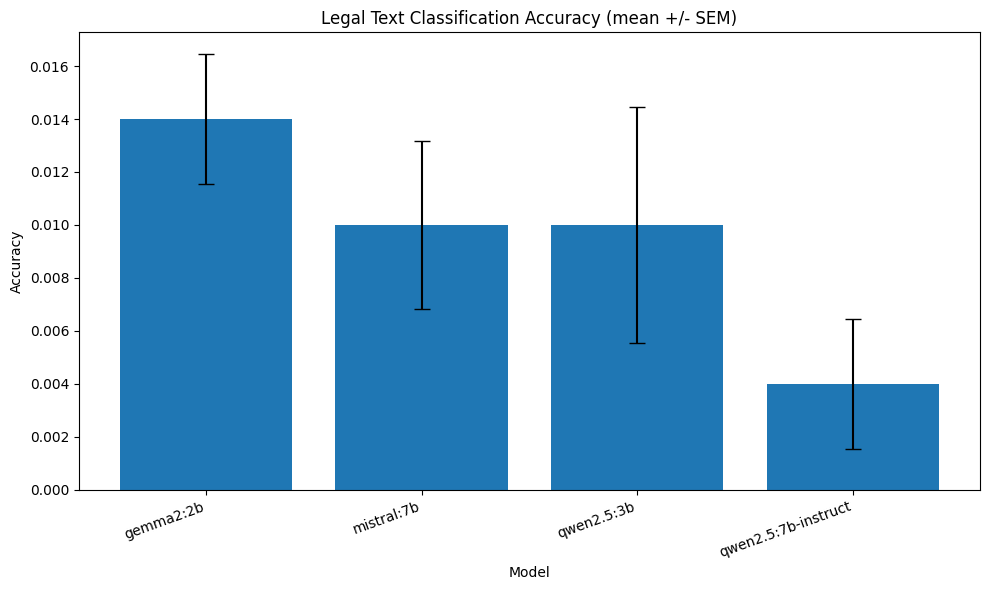

In [17]:
display(repeated_summary)

metric = "accuracy_mean"
sem_column = "accuracy_sem"
ranked = aggregated_summary.sort_values(metric, ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.bar(ranked["model"], ranked[metric], yerr=ranked[sem_column].fillna(0.0), capsize=6)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Legal Text Classification Accuracy (mean +/- SEM)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [18]:
!zip legal_text_classification_colab.zip -r results/legal_text_classification_colab

  adding: results/legal_text_classification_colab/ (stored 0%)
  adding: results/legal_text_classification_colab/legal_text_classification/ (stored 0%)
  adding: results/legal_text_classification_colab/legal_text_classification/repeat_01/ (stored 0%)
  adding: results/legal_text_classification_colab/legal_text_classification/repeat_01/legal_text_classification_summary.csv (deflated 47%)
  adding: results/legal_text_classification_colab/legal_text_classification/repeat_01/legal_text_classification_visualization.html (deflated 84%)
  adding: results/legal_text_classification_colab/legal_text_classification/repeat_01/legal_text_classification_predictions.csv (deflated 77%)
  adding: results/legal_text_classification_colab/legal_text_classification/repeat_05/ (stored 0%)
  adding: results/legal_text_classification_colab/legal_text_classification/repeat_05/legal_text_classification_summary.csv (deflated 45%)
  adding: results/legal_text_classification_colab/legal_text_classification/repeat_